In [1]:
import pandas as pd 

df = pd.read_csv('spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train,x_test,y_train,y_test = train_test_split(df.Message , df.Category , test_size=0.2,random_state=5)

In [7]:
x_train

1658    S:-)if we have one good partnership going we w...
1509    Sounds like something that someone testing me ...
3266    44 7732584351, Do you want a New Nokia 3510i c...
5199           Ugh my leg hurts. Musta overdid it on mon.
3217    URGENT! We are trying to contact U. Todays dra...
                              ...                        
3046    Hello, yeah i've just got out of the bath and ...
1725              There bold 2  &lt;#&gt; . Is that yours
4079                  Gam gone after outstanding innings.
2254                         Lol enjoy role playing much?
2915    Sorry! U can not unsubscribe yet. THE MOB offe...
Name: Message, Length: 4457, dtype: object

In [8]:
y_train

1658     ham
1509     ham
3266    spam
5199     ham
3217    spam
        ... 
3046     ham
1725     ham
4079     ham
2254     ham
2915    spam
Name: Category, Length: 4457, dtype: object

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()
x_train_count = v.fit_transform(x_train)
x_test_count = v.transform(x_test)
x_train_count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 59063 stored elements and shape (4457, 7705)>

In [11]:
len(x_train_count.toarray()[1])

7705

# Model Evaluation : Precision , Recall , F1 Score


In [15]:
from sklearn.naive_bayes import MultinomialNB , GaussianNB

model = MultinomialNB()
model.fit(x_train_count , y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test_count)

report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



# Model Training : Confusion Matrix

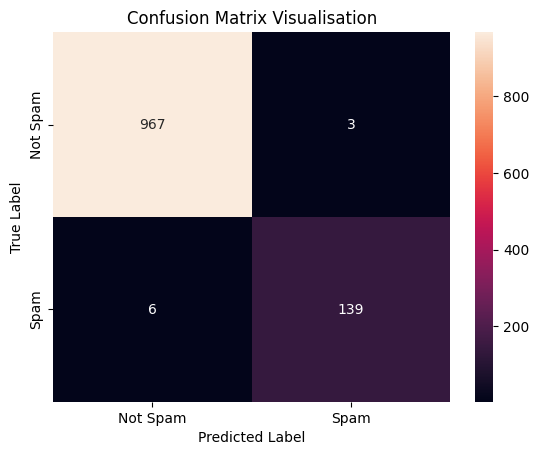

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt 

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm , annot=True , fmt ='d', xticklabels=['Not Spam', 'Spam'] , yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualisation')
plt.show()

In [22]:
email = [
    'Hey Mohan , can we get together to watch football game tomorrow ? ',
    'Upto 20% discount on parking , exclusive offer just for you. Dont miss this reward!'
]

email_count = v.transform(email)
model.predict(email_count)

array(['ham', 'spam'], dtype='<U4')

In [23]:
model.predict_proba(email_count)

array([[9.99980509e-01, 1.94913008e-05],
       [1.16454213e-02, 9.88354579e-01]])

In [25]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('count_vectorizer' , CountVectorizer()),
    ('nb_classifier', MultinomialNB())
])

pipe.fit(x_train , y_train)

y_pred = pipe.predict(x_test)
report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

